
Starting Training with Undersampling and Class Weights...
Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 571s 2s/step - accuracy: 0.5797 - auc: 0.6311 - loss: 1.9062 - recall: 0.6613 - val_accuracy: 0.4888 - val_auc: 0.4892 - val_loss: 0.7289 - val_recall: 0.0000e+00
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.6707 - auc: 0.8191 - loss: 1.0567 - recall: 0.9823 - val_accuracy: 0.4913 - val_auc: 0.6065 - val_loss: 0.7002 - val_recall: 0.0218
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 250s 836ms/step - accuracy: 0.7052 - auc: 0.8615 - loss: 0.8809 - recall: 0.9935 - val_accuracy: 0.6400 - val_auc: 0.7205 - val_loss: 0.6396 - val_recall: 0.3868
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 264s 884ms/step - accuracy: 0.7625 - auc: 0.8446 - loss: 0.8770 - recall: 0.9864 - val_accuracy: 0.7250 - val_auc: 0.8140 - val_loss: 0.5422 - val_recall: 0.7316
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 243s 813ms/step - accuracy: 0.7570 - auc: 0.8572 - loss: 0.8516 - recall: 0.9927 - val_accuracy: 0.6

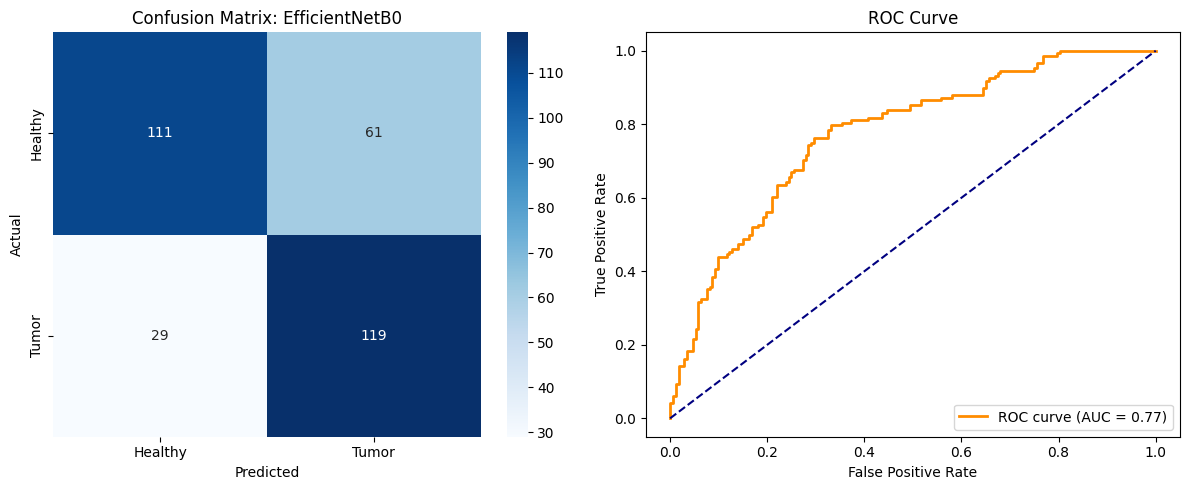


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.79      0.65      0.71       172
       Tumor       0.66      0.80      0.73       148

    accuracy                           0.72       320
   macro avg       0.73      0.72      0.72       320
weighted avg       0.73      0.72      0.72       320



In [2]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils import class_weight

# ---------------- 1. CONFIGURATION ----------------
IMG_SIZE = 224
BATCH_SIZE = 16
STEPS_PER_EPOCH = 300  # Adjust based on your dataset size
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# ---------------- 2. FILE LOADING (Hidden File Fix) ----------------
all_patients = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if (f.endswith(".nii") or f.endswith(".nii.gz")) and not f.startswith(".")
])

train_pats, test_pats = train_test_split(all_patients, test_size=0.2, random_state=42)

# ---------------- 3. BALANCED GENERATOR (Undersampling) ----------------
def balanced_slice_generator(patient_list):
    """
    UNDERSAMPLING: We keep all tumor slices, but only 10% of healthy slices.
    """
    while True:
        np.random.shuffle(patient_list)
        for pat in patient_list:
            try:
                img_vol = nib.load(os.path.join(IMAGE_DIR, pat)).get_fdata()
                mask_vol = nib.load(os.path.join(MASK_DIR, pat)).get_fdata()
                
                for i in range(img_vol.shape[2]):
                    is_tumor = np.any(mask_vol[:, :, i] == 2)
                    
                    # UNDERSAMPLING LOGIC
                    if not is_tumor and np.random.random() > 0.1:
                        continue # Skip 90% of healthy slices
                    
                    # Preprocessing
                    slice_img = np.clip(img_vol[:, :, i], -100, 200)
                    slice_img = (slice_img + 100) / 300.0
                    slice_img = np.stack([slice_img]*3, axis=-1)
                    slice_img = cv2.resize(slice_img, (IMG_SIZE, IMG_SIZE))
                    
                    yield slice_img, int(is_tumor)
            except Exception:
                continue

import cv2 # Ensure cv2 is imported for resize

# ---------------- 4. TF.DATA PIPELINE ----------------
train_ds = tf.data.Dataset.from_generator(
    lambda: balanced_slice_generator(train_pats),
    output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: balanced_slice_generator(test_pats),
    output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ---------------- 5. CLASS WEIGHTS ----------------
# We assign higher weight to Class 1 (Tumor) to penalize missing a tumor more heavily
class_weights = {0: 1.0, 1: 5.0} 

# ---------------- 6. BUILD MODEL ----------------
def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = True
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')])
    return model

model = build_efficientnet()

# ---------------- 7. TRAINING ----------------
print("\nStarting Training with Undersampling and Class Weights...")
model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=50,
    class_weight=class_weights # Applying Class Weights here
)

# ---------------- 8. EVALUATION & VISUALIZATION ----------------
print("\nGenerating Evaluation Metrics...")

y_true, y_probs = [], []
# Take a sample from the test generator for final metrics
for img_batch, label_batch in test_ds.take(20):
    preds = model.predict(img_batch, verbose=0)
    y_probs.extend(preds.flatten())
    y_true.extend(label_batch.numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Tumor'], yticklabels=['Healthy', 'Tumor'])
plt.title('Confusion Matrix: EfficientNetB0')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Tumor']))